In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'AppleGothic'  # Mac 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지

print("pandas", pd.__version__)
print("numpy", np.__version__)
print("seaborn", sns.__version__)
print("준비 완료!")

pandas 2.2.2
numpy 1.26.4
seaborn 0.13.2
준비 완료!


In [3]:
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')
df.head()
# dataset size 측정
# 953개 행, 24개 컬럼
print(df.shape)

(953, 24)


## 1단계 — 데이터 전처리
목표: 결측치 확인, 데이터 타입 점검 및 정제

In [5]:
# 결측치 확인
df.isnull().sum()
# in_shazam_charts 결측치 50개, key 결측치 95개

track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64

In [ ]:
# null이 아닌 데이터 수 계산
df.count()

In [ ]:
# dataset 타입 확인
df.dtypes
# 문제 - streams 숫자처럼 보이는데 object type > 집계할 때 문제가 생긴다.

In [6]:
# streams 컬럼이 object인 이유가 숫자가 아닌 값(쉼표, 문자 등)이 섞여 있을 수 있기 때문에
# errors 옵션을 추가해서 강제로 처리
# errors='coerce' 숫자로 변환 불가능한 값은 NaN으로 변경
df["streams"] = pd.to_numeric(df["streams"], errors='coerce')

In [7]:
# 숫자로 변환되지 않아 결측치가 된 데이터가 있는지 확인
# 953개 중 1개 결측 - 데이터의 0.1% 정도기 때문에 행을 제거하는 것이 낫다
# 평균으로 대체 X - BTS와 신인 아티스트가 같은 데이터 안에 있기 때문에 평균이 실제 스트리밍 수를 대표할 수 없다
df["streams"].isnull().sum()

1

In [8]:
# streams 컬럼 기준으로만 제거
df = df.dropna(subset=['streams'])
print(df.shape)

(952, 24)


### 1단계 — 결과

- `streams` 컬럼이 object 타입 → `pd.to_numeric()`으로 int64 변환
- 변환 과정에서 NaN 1개 발생 (전체의 0.1%) → `dropna()`로 제거
- 최종 데이터: 952행, 24컬럼
- 결측치: `key` 95개, `in_shazam_charts` 50개 → 분석 시 그때그때 처리

## 2단계 - 아티스트 & 트랙 집계 분석

In [9]:
# 스트리밍 Top 10 아티스트
# 지수 표기법에서 숫자 포맷 변경
pd.options.display.float_format = '{:,.0f}'.format
df.groupby("artist(s)_name")["streams"].sum().sort_values(ascending=False).head(10)

artist(s)_name
The Weeknd        14,185,552,870
Taylor Swift      14,053,658,300
Ed Sheeran        13,908,947,204
Harry Styles      11,608,645,649
Bad Bunny          9,997,799,607
Olivia Rodrigo     7,442,148,916
Eminem             6,183,805,596
Bruno Mars         5,846,920,599
Arctic Monkeys     5,569,806,731
Imagine Dragons    5,272,484,650
Name: streams, dtype: float64

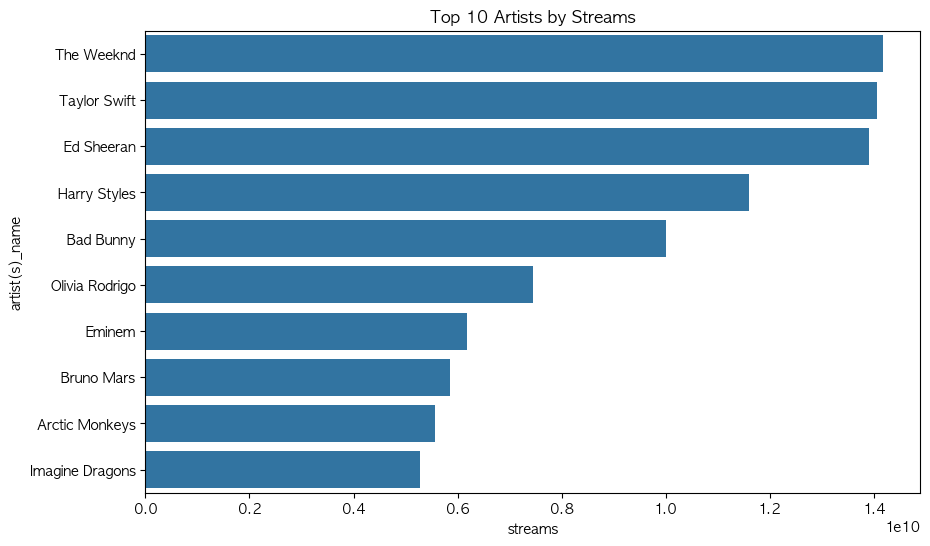

In [10]:
# df.groupby("artist(s)_name")["streams"].sum().sort_values(ascending=False).head(10) Series(1차원)로 출력된다.
# barplot으로 시각화 하기 위해서는 DataFrame(2차원)이 필요함
# reset_index()로 index로 되어 있던 artist(s)_name을 컬럼으로 꺼내줘야한다.
top10 = df.groupby("artist(s)_name")["streams"].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=top10,x="streams",y="artist(s)_name")
plt.title("Top 10 Artists by Streams")
plt.show()

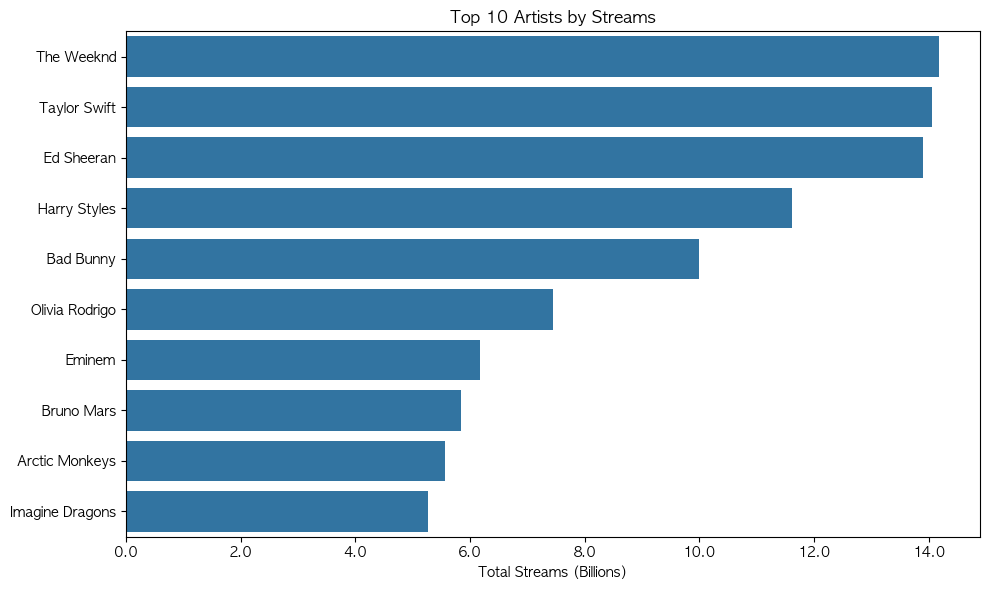

In [11]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x="streams", y="artist(s)_name")
plt.title("Top 10 Artists by Streams")
plt.xlabel("Total Streams (Billions)")
plt.ylabel("")
# plt.ticklabel_format(style="plain", axis="x")  # 지수 표기 제거
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e9:.1f}')) #
plt.tight_layout() # 제목, 축 레이블, 눈금이 서로 겹치지 않게 자동으로 여백을 조정
plt.show()

## 3단계 오디오 피처 상관관계 분석

In [ ]:
# 상관관계 분석하려면 수치형 컬럼만 뽑아야 한다.
df.select_dtypes("number")

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,2,2023,7,14,553,147,"141,381,703",43,263,10,125,80,89,83,31,0,8,4
1,1,2023,3,23,1474,48,"133,716,286",48,126,14,92,71,61,74,7,0,10,4
2,1,2023,6,30,1397,113,"140,003,974",94,207,14,138,51,32,53,17,0,31,6
3,1,2019,8,23,7858,100,"800,840,817",116,207,12,170,55,58,72,11,0,11,15
4,1,2023,5,18,3133,50,"303,236,322",84,133,15,144,65,23,80,14,63,11,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,1,2022,11,3,953,0,"91,473,363",61,13,1,144,60,24,39,57,0,8,3
949,1,2022,10,21,1180,0,"121,871,870",4,0,0,166,42,7,24,83,1,12,6
950,2,2022,11,3,573,0,"73,513,683",2,0,0,92,80,81,67,4,0,8,6
951,3,2022,10,20,1320,0,"133,895,612",29,26,0,97,82,67,77,8,0,12,5


In [19]:
# 방법 1 — 직접 리스트로
# audio_features = df[["danceability_%", "valence_%", ...]]

# 방법 2 — 컬럼명 패턴으로
audio_features = df[[col for col in df.columns if col.endswith("_%")]]

In [29]:
# 오디오피쳐 컬럼들 간의 상관관계 구하기
corr_matrix = audio_features.corr()
print(corr_matrix.round(4))

                    danceability_%  valence_%  energy_%  acousticness_%  \
danceability_%                   1          0         0              -0   
valence_%                        0          1         0              -0   
energy_%                         0          0         1              -1   
acousticness_%                  -0         -0        -1               1   
instrumentalness_%              -0         -0        -0               0   
liveness_%                      -0          0         0              -0   
speechiness_%                    0          0        -0              -0   

                    instrumentalness_%  liveness_%  speechiness_%  
danceability_%                      -0          -0              0  
valence_%                           -0           0              0  
energy_%                            -0           0             -0  
acousticness_%                       0          -0             -0  
instrumentalness_%                   1          -0         

In [30]:
print(corr_matrix['energy_%']['acousticness_%'])

-0.5773182106878039


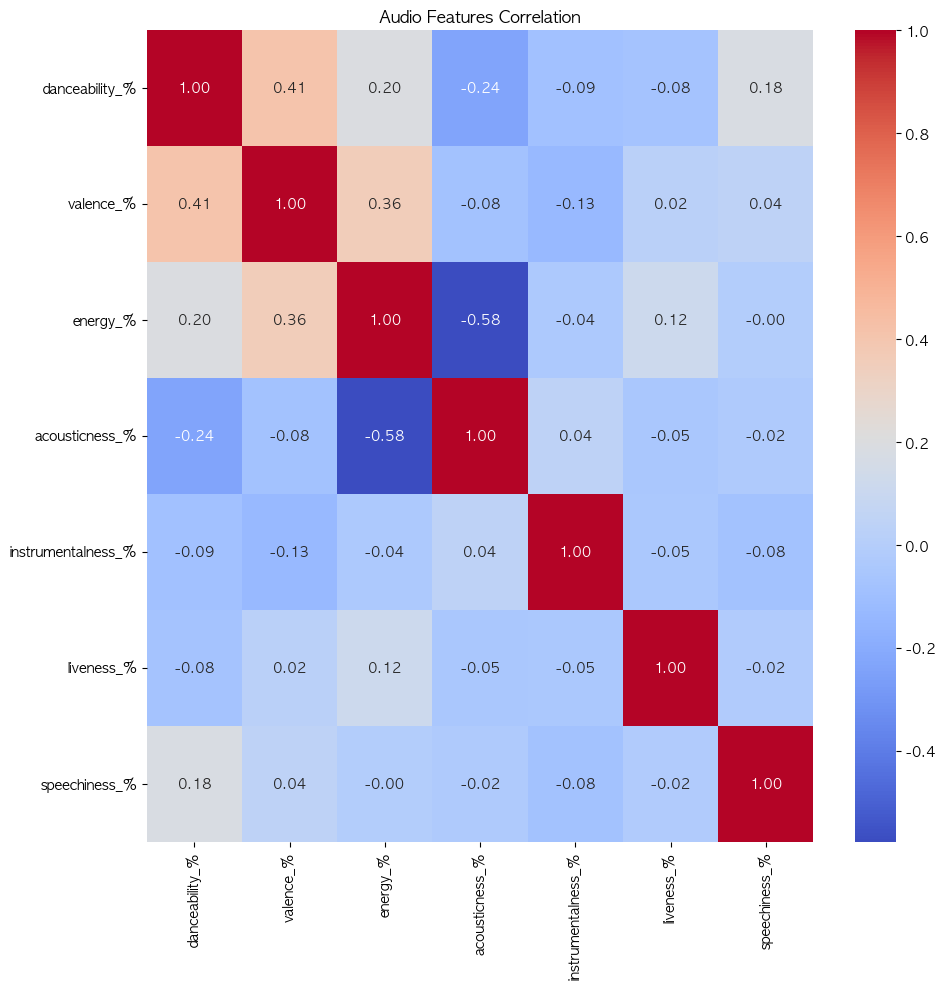

In [37]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Audio Features Correlation")
plt.tight_layout()
plt.show()

### 결과
heatmap을 활용하여 오디오피쳐들 간의 상관관계를 분석한 결과는 아래와 같다.
- energy ↔ acousticness = -0.58 → 강한 음의 상관관계. 에너지 넘치는 곡일수록 어쿠스틱하지 않음
- danceability ↔ valence = 0.41 → 중간 양의 상관관계. 신나는 곡이 긍정적인 감정도 높음
- energy ↔ valence = 0.36 → 중간 양의 상관관계. 에너지 넘치는 곡이 긍정적인 감정도 높음
- danceability ↔ speechiness = 0.18 → 거의 관계 없음

** 범위해석 **\
0.7         이상강한 상관\
0.4 ~ 0.7   중간 상관\
0.2 ~ 0.4   약한 상관\
0.2         미만거의 없음
